In [12]:
import os
import sys
import math
import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from torch.utils.data import DataLoader

In [13]:
p = Path.cwd().resolve()
repo_root = next(parent for parent in [p, *p.parents] if (parent / "scripts").exists())
sys.path.insert(0, str(repo_root / "scripts"))

In [14]:
from voc_datasets import (
    build_voc_datasets,
    VOC_CLASSES,
    NUM_CLASSES,
    IGNORE_INDEX,
)

from metrics import (
    compute_pixel_accuracy,
    compute_mean_iou,
    compute_mean_dice,
    compute_per_class_iou,
    compute_per_class_dice,
    compute_per_class_accuracy,
    compute_confusion_matrix,
)

# SAM2 imports
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

In [15]:
ROOT = r"c:/Users/Kwame Boateng/Documents/GitHub/semantic-segmentation/Data"
IMG_SIZE = 256
BATCH_SIZE = 1   # keep this 1 for simpler SAM2 image-wise inference
NUM_WORKERS = 0

# Change these to match the checkpoint + config you actually downloaded
SAM2_CONFIG = "configs/sam2.1/sam2.1_hiera_l.yaml"
SAM2_CHECKPOINT = "checkpoints/sam2.1_hiera_large.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [16]:
train_dataset, val_dataset = build_voc_datasets(
    root=ROOT,
    img_size=IMG_SIZE,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
)

print("Validation samples:", len(val_dataset))

Validation samples: 213


In [17]:
sam2_model = build_sam2(SAM2_CONFIG, SAM2_CHECKPOINT, device=device)
predictor = SAM2ImagePredictor(sam2_model)

print("SAM2 predictor ready.")

SAM2 predictor ready.


In [18]:
def tensor_to_uint8_image(image_tensor):
    """
    Convert image tensor (3, H, W) in [0,1] to uint8 numpy image (H, W, 3).
    """
    image = image_tensor.permute(1, 2, 0).cpu().numpy()
    image = np.clip(image * 255.0, 0, 255).astype(np.uint8)
    return image

In [19]:
def get_binary_mask(mask, class_id):
    return (mask == class_id).astype(np.uint8)


def get_bounding_box(binary_mask):
    """
    Returns box in XYXY format: [x_min, y_min, x_max, y_max]
    """
    ys, xs = np.where(binary_mask > 0)

    if len(xs) == 0 or len(ys) == 0:
        return None

    x_min = xs.min()
    x_max = xs.max()
    y_min = ys.min()
    y_max = ys.max()

    return np.array([x_min, y_min, x_max, y_max], dtype=np.float32)


def get_positive_point(binary_mask):
    """
    Choose a positive point from the object mask.
    Uses centroid if possible, else first foreground pixel.
    Returns shape (1, 2) as [[x, y]]
    """
    ys, xs = np.where(binary_mask > 0)

    if len(xs) == 0 or len(ys) == 0:
        return None

    x_center = int(np.round(xs.mean()))
    y_center = int(np.round(ys.mean()))

    if binary_mask[y_center, x_center] > 0:
        return np.array([[x_center, y_center]], dtype=np.float32)

    return np.array([[xs[0], ys[0]]], dtype=np.float32)

In [20]:
def show_prediction(image, true_mask, pred_mask, class_names, ignore_index=255):
    image = image.copy()
    true_mask = true_mask.copy()
    pred_mask = pred_mask.copy()

    true_mask[true_mask == ignore_index] = 0

    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(true_mask, cmap="tab20", vmin=0, vmax=len(class_names) - 1)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_mask, cmap="tab20", vmin=0, vmax=len(class_names) - 1)
    plt.title("SAM2 Prediction")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

In [21]:
def predict_semantic_mask_with_sam2(
    predictor,
    image_uint8,
    gt_mask_tensor,
    num_classes,
    ignore_index=255,
):
    """
    Build a semantic prediction map using GT-derived box + positive point prompts.
    Returns:
        pred_map: (H, W) int64 numpy array with class IDs
    """
    gt_mask = gt_mask_tensor.cpu().numpy()
    h, w = gt_mask.shape

    predictor.set_image(image_uint8)

    pred_map = np.zeros((h, w), dtype=np.int64)

    # We will process all foreground classes present in the GT mask.
    # Skip background=0 and ignore_index=255.
    present_classes = np.unique(gt_mask)
    present_classes = [c for c in present_classes if c != 0 and c != ignore_index]

    # Track mask quality scores to help with overlap conflicts.
    score_map = np.full((h, w), -np.inf, dtype=np.float32)

    for class_id in present_classes:
        binary_mask = get_binary_mask(gt_mask, class_id)

        box = get_bounding_box(binary_mask)
        point_coords = get_positive_point(binary_mask)

        if box is None or point_coords is None:
            continue

        point_labels = np.array([1], dtype=np.int32)

        masks, scores, _ = predictor.predict(
            point_coords=point_coords,
            point_labels=point_labels,
            box=box[None, :],
            multimask_output=True,
        )

        best_idx = int(np.argmax(scores))
        best_mask = masks[best_idx].astype(bool)
        best_score = float(scores[best_idx])

        # Resolve overlaps by keeping the class with the higher SAM2 score
        update_region = best_mask & (best_score > score_map)
        pred_map[update_region] = class_id
        score_map[update_region] = best_score

    # Preserve ignore pixels from GT so they do not affect evaluation
    pred_map[gt_mask == ignore_index] = ignore_index

    return pred_map

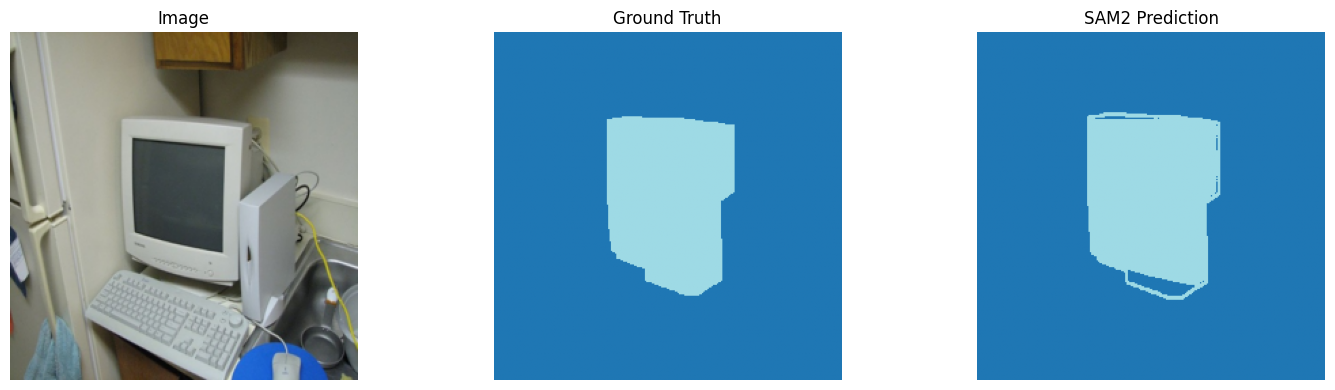

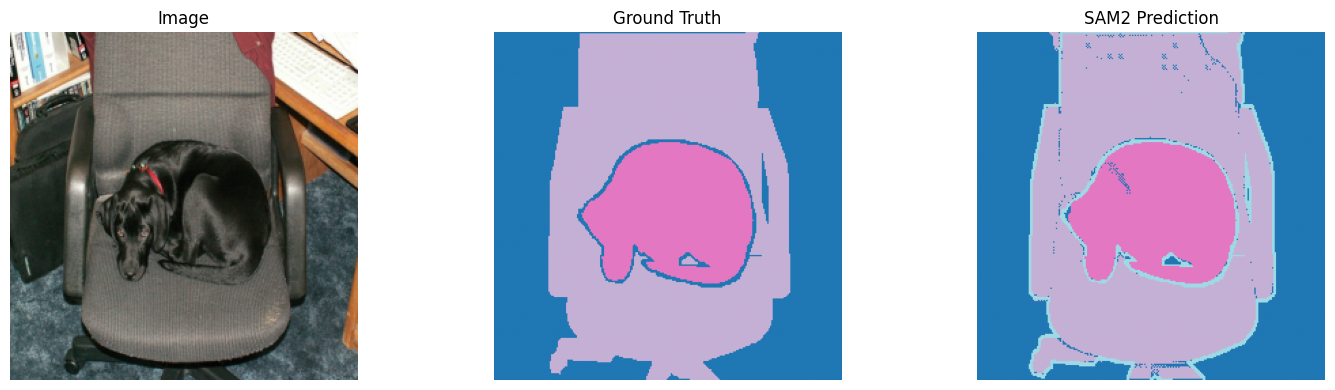

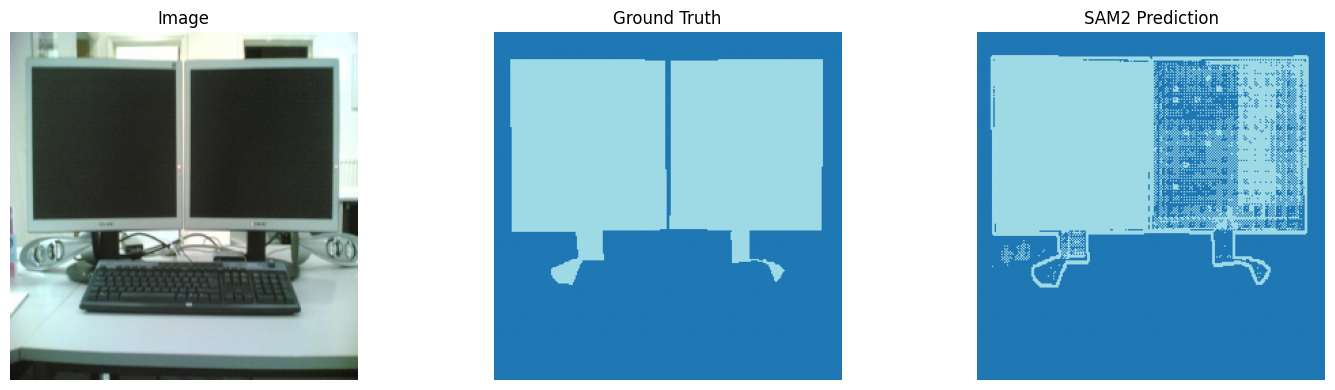

In [22]:
num_examples = 3
shown = 0

for images, masks in val_loader:
    image_tensor = images[0]
    mask_tensor = masks[0]

    image_uint8 = tensor_to_uint8_image(image_tensor)
    pred_map = predict_semantic_mask_with_sam2(
        predictor=predictor,
        image_uint8=image_uint8,
        gt_mask_tensor=mask_tensor,
        num_classes=NUM_CLASSES,
        ignore_index=IGNORE_INDEX,
    )

    show_prediction(
        image_uint8,
        mask_tensor.cpu().numpy(),
        pred_map,
        VOC_CLASSES,
        IGNORE_INDEX,
    )

    shown += 1
    if shown >= num_examples:
        break

In [23]:
all_preds = []
all_targets = []
all_images = []

for images, masks in val_loader:
    image_tensor = images[0]
    mask_tensor = masks[0]

    image_uint8 = tensor_to_uint8_image(image_tensor)

    pred_map = predict_semantic_mask_with_sam2(
        predictor=predictor,
        image_uint8=image_uint8,
        gt_mask_tensor=mask_tensor,
        num_classes=NUM_CLASSES,
        ignore_index=IGNORE_INDEX,
    )

    all_preds.append(torch.from_numpy(pred_map).long())
    all_targets.append(mask_tensor.long())
    all_images.append(torch.from_numpy(image_uint8))

all_preds = torch.stack(all_preds, dim=0)
all_targets = torch.stack(all_targets, dim=0)

print("all_preds shape:", all_preds.shape)
print("all_targets shape:", all_targets.shape)

all_preds shape: torch.Size([213, 256, 256])
all_targets shape: torch.Size([213, 256, 256])


In [24]:
overall_pixel_acc = compute_pixel_accuracy(all_preds, all_targets, IGNORE_INDEX)
overall_miou = compute_mean_iou(all_preds, all_targets, NUM_CLASSES, IGNORE_INDEX)
overall_mdice = compute_mean_dice(all_preds, all_targets, NUM_CLASSES, IGNORE_INDEX)

print("SAM2 Final Evaluation Summary")
print(f"Pixel Accuracy: {overall_pixel_acc:.4f}")
print(f"Mean IoU: {overall_miou:.4f}")
print(f"Mean Dice: {overall_mdice:.4f}")

SAM2 Final Evaluation Summary
Pixel Accuracy: 0.9380
Mean IoU: 0.7716
Mean Dice: 0.8528


In [25]:
per_class_iou = compute_per_class_iou(
    all_preds,
    all_targets,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)

per_class_dice = compute_per_class_dice(
    all_preds,
    all_targets,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)

per_class_acc = compute_per_class_accuracy(
    all_preds,
    all_targets,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)

print(f"{'Class':<15} {'IoU':>10} {'Dice':>10} {'Acc':>10}")
for i, name in enumerate(VOC_CLASSES):
    iou = per_class_iou[i].item() if not torch.isnan(per_class_iou[i]) else float("nan")
    dice = per_class_dice[i].item() if not torch.isnan(per_class_dice[i]) else float("nan")
    acc = per_class_acc[i].item() if not torch.isnan(per_class_acc[i]) else float("nan")
    print(f"{name:<15} {iou:>10.4f} {dice:>10.4f} {acc:>10.4f}")

Class                  IoU       Dice        Acc
background          0.9228     0.9599     0.9829
aeroplane           0.9475     0.9731     0.9594
bicycle             0.4041     0.5756     0.7776
bird                0.8284     0.9062     0.8346
boat                0.8311     0.9078     0.8461
bottle              0.6472     0.7858     0.7181
bus                 0.8909     0.9423     0.8941
car                 0.7699     0.8700     0.8636
cat                 0.9026     0.9488     0.9046
chair               0.5410     0.7022     0.6297
cow                 0.9260     0.9616     0.9280
diningtable         0.5490     0.7088     0.5667
dog                 0.9258     0.9615     0.9363
horse               0.9330     0.9653     0.9360
motorbike           0.9081     0.9518     0.9390
person              0.6918     0.8178     0.7009
pottedplant         0.1731     0.2951     0.3698
sheep               0.7908     0.8832     0.8323
sofa                0.8755     0.9336     0.8936
train               

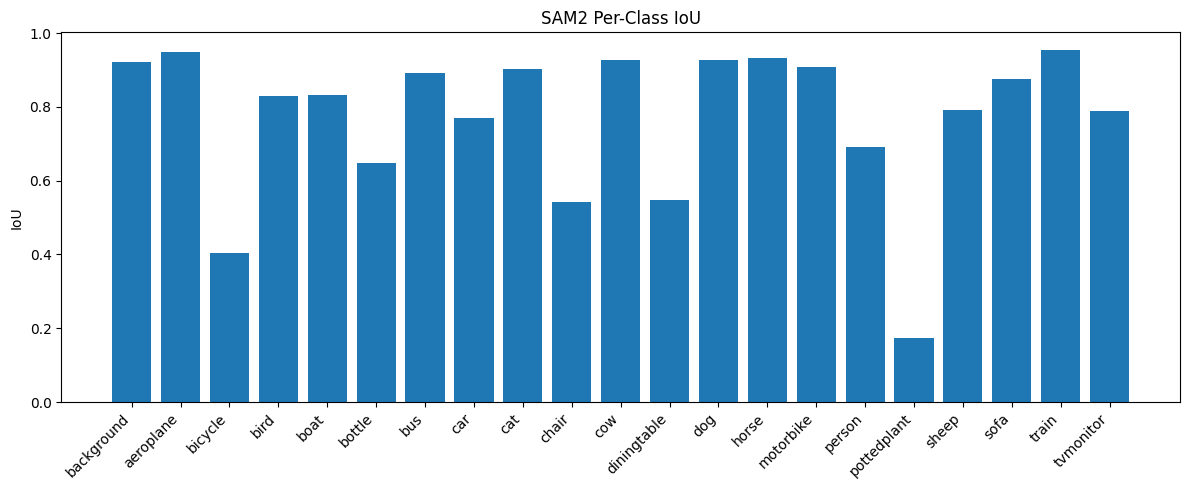

In [26]:
iou_values = per_class_iou.cpu().numpy()

plt.figure(figsize=(12, 5))
plt.bar(range(NUM_CLASSES), np.nan_to_num(iou_values, nan=0.0))
plt.xticks(range(NUM_CLASSES), VOC_CLASSES, rotation=45, ha="right")
plt.ylabel("IoU")
plt.title("SAM2 Per-Class IoU")
plt.tight_layout()
plt.show()

In [27]:
cm = compute_confusion_matrix(
    all_preds,
    all_targets,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)

print("Confusion matrix shape:", cm.shape)
cm

Confusion matrix shape: torch.Size([21, 21])


tensor([[9642501,    1506,   26333,     933,     985,    7154,      46,   10140,
             650,   18456,     239,     663,    1185,     379,    3831,    9313,
           72398,   11637,      84,     628,    1059],
        [   4928,  116352,       0,       0,       0,       0,       0,       0,
               0,       0,       0,       0,       0,       0,       0,       2,
               0,       0,       0,       0,       0],
        [   6220,       0,   22368,       0,       0,       0,       0,       0,
               0,       0,       0,       0,       0,       0,       0,     179,
               0,       0,       0,       0,       0],
        [  20898,       0,       0,  105529,       0,       0,       0,       0,
               0,       0,       0,       0,       0,       0,       0,      10,
               0,       0,       0,       0,       0],
        [   9227,       0,       0,       0,   50754,       0,       0,       0,
               0,       0,       0,       0,       

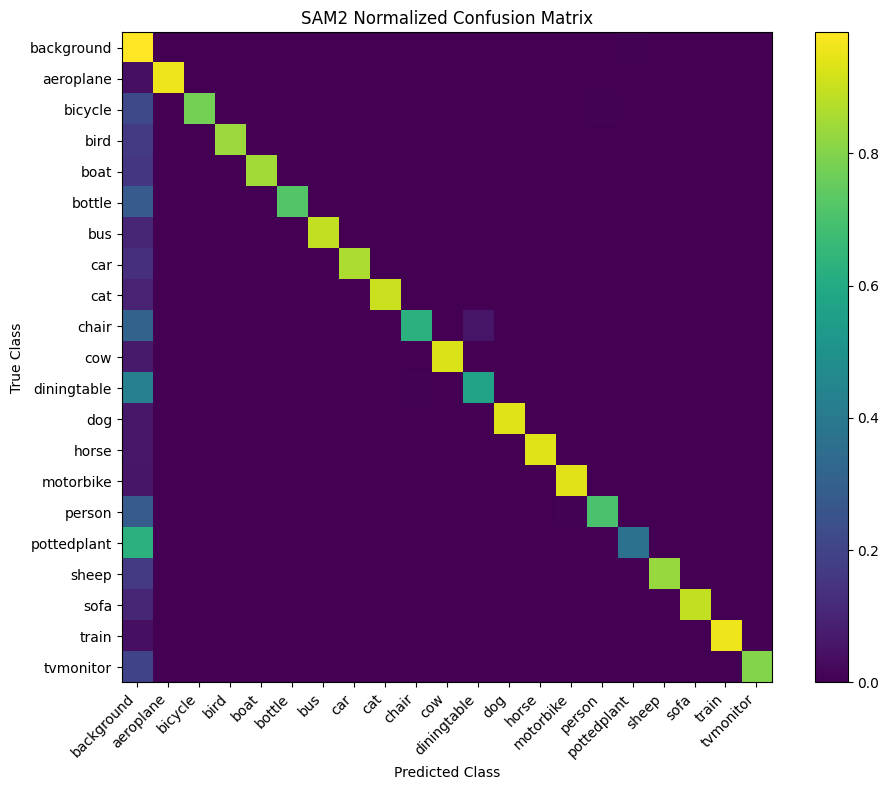

In [28]:
cm_np = cm.cpu().numpy().astype(np.float64)
row_sums = cm_np.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm_np, row_sums, where=row_sums != 0)

plt.figure(figsize=(10, 8))
plt.imshow(cm_norm, interpolation="nearest")
plt.title("SAM2 Normalized Confusion Matrix")
plt.colorbar()
plt.xticks(range(NUM_CLASSES), VOC_CLASSES, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), VOC_CLASSES)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.show()

In [29]:
def compute_sample_iou(pred_mask, true_mask, num_classes, ignore_index=255):
    return compute_mean_iou(
        pred_mask.unsqueeze(0),
        true_mask.unsqueeze(0),
        num_classes=num_classes,
        ignore_index=ignore_index,
    )

sample_scores = []

for i in range(len(all_preds)):
    miou = compute_sample_iou(all_preds[i], all_targets[i], NUM_CLASSES, IGNORE_INDEX)
    sample_scores.append({"index": i, "mean_iou": miou})

sample_scores = sorted(sample_scores, key=lambda x: x["mean_iou"], reverse=True)

print("Best sample:", sample_scores[0])
print("Worst sample:", sample_scores[-1])

Best sample: {'index': 191, 'mean_iou': 0.9995632767677307}
Worst sample: {'index': 6, 'mean_iou': 0.09646689146757126}


Best examples:
{'index': 191, 'mean_iou': 0.9995632767677307}


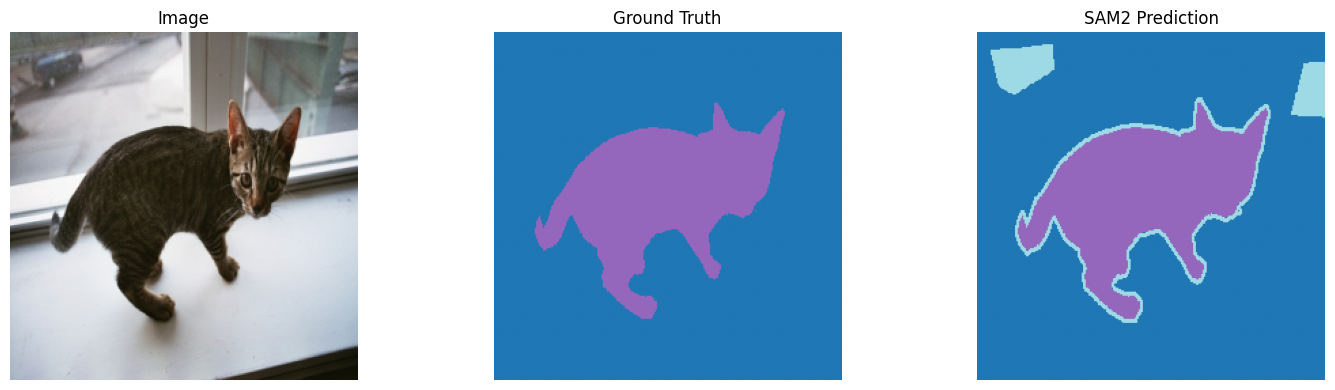

{'index': 32, 'mean_iou': 0.99901282787323}


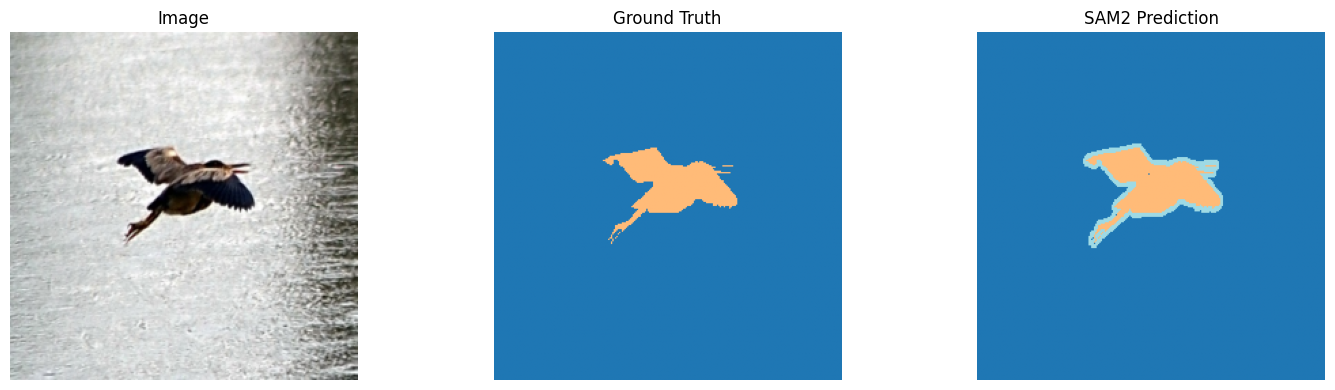

{'index': 45, 'mean_iou': 0.9987961053848267}


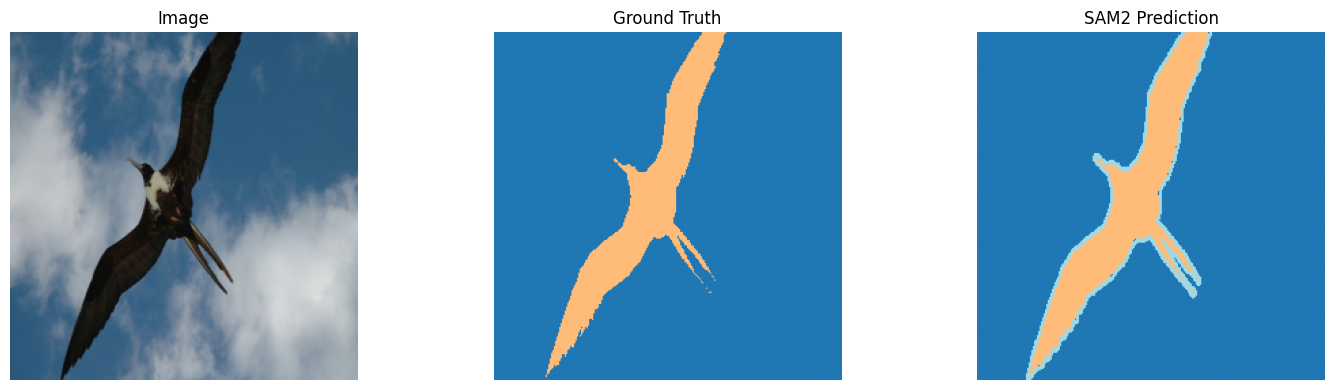

In [30]:
top_k = 3

print("Best examples:")
for entry in sample_scores[:top_k]:
    idx = entry["index"]
    image_uint8 = all_images[idx].numpy()
    true_mask = all_targets[idx].numpy()
    pred_mask = all_preds[idx].numpy()

    print(entry)
    show_prediction(image_uint8, true_mask, pred_mask, VOC_CLASSES, IGNORE_INDEX)

Worst examples:
{'index': 30, 'mean_iou': 0.22907713055610657}


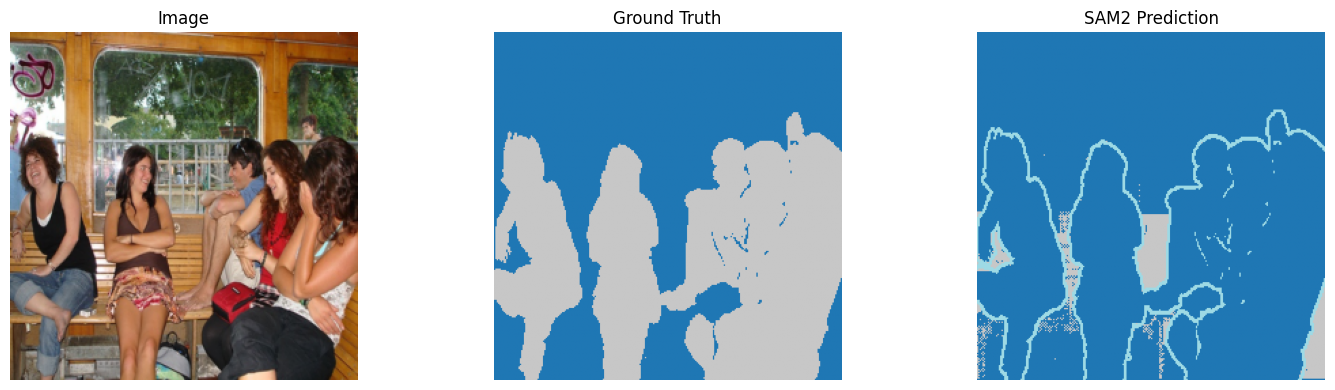

{'index': 66, 'mean_iou': 0.17896142601966858}


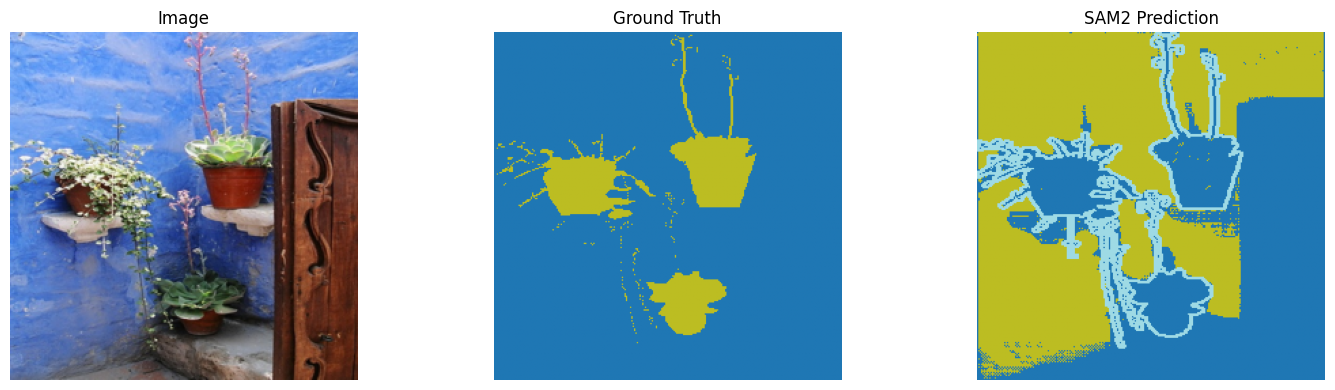

{'index': 6, 'mean_iou': 0.09646689146757126}


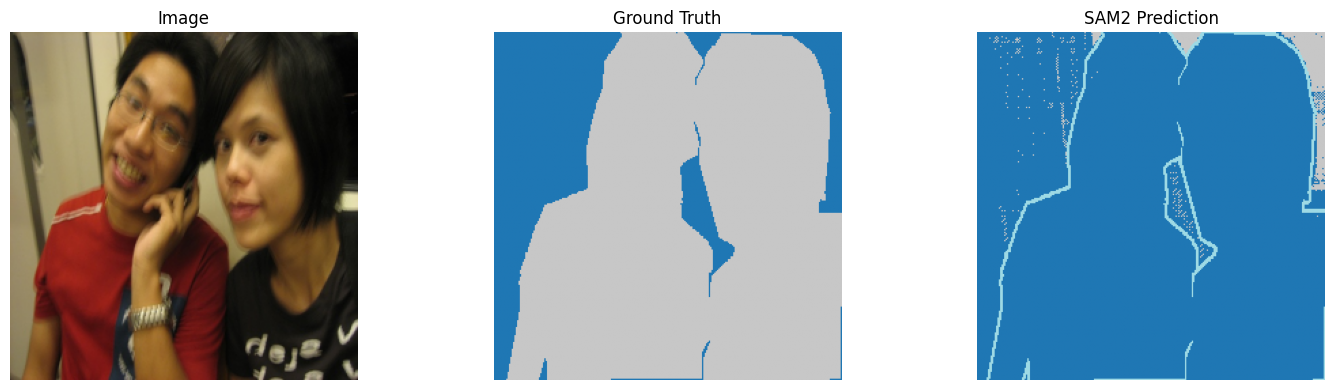

In [31]:
top_k = 3

print("Worst examples:")
for entry in sample_scores[-top_k:]:
    idx = entry["index"]
    image_uint8 = all_images[idx].numpy()
    true_mask = all_targets[idx].numpy()
    pred_mask = all_preds[idx].numpy()

    print(entry)
    show_prediction(image_uint8, true_mask, pred_mask, VOC_CLASSES, IGNORE_INDEX)

In [33]:
from metrics import compute_hd95

per_class_hd95 = compute_hd95(
    all_preds,
    all_targets,
    num_classes=NUM_CLASSES,
    ignore_index=IGNORE_INDEX,
)

print(f"{'Class':<15} {'HD95':>10}")
for i, name in enumerate(VOC_CLASSES):
    value = per_class_hd95[i].item() if not torch.isnan(per_class_hd95[i]) else float("nan")
    print(f"{name:<15} {value:>10.4f}")

Class                 HD95
background         17.0309
aeroplane          11.9393
bicycle            12.8589
bird               10.9277
boat               12.6360
bottle             15.3769
bus                21.8128
car                17.7176
cat                13.9143
chair              14.3127
cow                 5.1501
diningtable        25.8309
dog                 8.6232
horse               8.3196
motorbike          12.9332
person             22.5660
pottedplant        23.5219
sheep              13.3745
sofa               14.3766
train               9.8952
tvmonitor           8.0548
